# 13e — Rating-Transition Markov Generator: Baseline Hazard Curves

Covers `chap13_credit11a-c`: the Kavvathas (2001) rounded 8-rating
transition matrix (the same matrix already used in Chapter 2's
`02a_ratings_and_transitions.ipynb` to demonstrate
`estimate_markov_generator` — see the note below), used here to derive
an implied hazard-rate term structure two different ways: a discrete-time
matrix-power approach (`credit11a`) and a continuous-time generator
approach (`credit11b`), compared side by side for the same 7
non-default ratings, plus the continuous-time default-time density
directly (`credit11c`).

**Continuity note:** the exact same Kavvathas 8x8 matrix (down to the
same 2-decimal rounding) already lives in this project's
`notebooks/hsf/02a_ratings_and_transitions.ipynb` as `P_kavvathas`, used
there to demonstrate `estimate_markov_generator` on a credit transition
matrix specifically. Retyped here as a literal, matching the source
`.m` script, rather than re-imported, since Chapter 13's scripts are
self-contained by design.

**Function-availability note:** `Survival_Markov_Generator.m` and
`Density_Markov_Generator.m` are absent from this `hfs-archive` checkout
but already ported as `quanttoolbox.credit.reduced_form.
{survival,density}_markov_generator`; `estimate_markov_generator` is
already ported as `quanttoolbox.sustainable_finance.entropy.
estimate_markov_generator` and already in production use in Chapter 2.
`sumr`/`seqa`/`lagn`/`miss` (`credit11a`'s GAUSS-style helpers) are
generic one-line `QuantToolbox/tools/` utilities, reproduced here as
small local functions rather than imported from a package.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import logm
from quanttoolbox.sustainable_finance.entropy import estimate_markov_generator
from quanttoolbox.credit.reduced_form import survival_markov_generator, density_markov_generator

color_blue      = "#1f77b4"
color_red       = "#d62728"
color_green     = "#2ca02c"
color_violet    = "#ff33ff"
color_limegreen = "#32ff32"
color_pink      = "#ffb6c1"
color_orchid    = "#da70d6"

colors = [color_blue, color_red, color_green, color_violet, color_limegreen, color_pink, color_orchid]

plt.rcParams["figure.dpi"] = 100

RATINGS = ["AAA", "AA", "A", "BBB", "BB", "B", "CCC"]

# Kavvathas (2001) rounded 8x8 transition matrix (rows/cols: AAA..CCC, D)
P = np.array([
    [92.82, 6.50, 0.56, 0.06, 0.06, 0.00, 0.00, 0.00],
    [0.63, 91.87, 6.64, 0.65, 0.06, 0.11, 0.04, 0.00],
    [0.08, 2.26, 91.66, 5.11, 0.61, 0.23, 0.01, 0.04],
    [0.05, 0.27, 5.84, 87.74, 4.74, 0.98, 0.16, 0.22],
    [0.04, 0.11, 0.64, 7.85, 81.14, 8.27, 0.89, 1.06],
    [0.00, 0.11, 0.30, 0.42, 6.75, 83.07, 3.86, 5.49],
    [0.19, 0.00, 0.38, 0.75, 2.44, 12.03, 60.71, 23.50],
    [0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 100.00],
])
P = P / P.sum(axis=1, keepdims=True)  # sumr(P): row-normalize
K = P.shape[0]


def panel_plot(t, curves, ylabel, ylim_max, xlim=150, ytick3=None):
    """Shared 2x2 panel layout: (AAA,AA), (A,BBB), (BB,B), (CCC alone)."""
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    pairs = [(0, 1), (2, 3), (4, 5), (6, None)]
    for iter_i, (ax, (c1, c2)) in enumerate(zip(axes.flat, pairs)):
        ax.plot(t, curves[:, c1], "-", color=colors[c1], linewidth=1.5, label=RATINGS[c1])
        if c2 is not None:
            ax.plot(t, curves[:, c2], "--", color=colors[c2], linewidth=1.5, label=RATINGS[c2])
        ax.grid(True, alpha=0.5)
        ax.set_xlabel("$t$", fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.legend(fontsize=10, loc="upper left")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_xlim(0, xlim)
        ax.set_ylim(0, ylim_max[iter_i])
        if iter_i == 2 and ytick3 is not None:
            ax.set_yticks(ytick3)
    plt.tight_layout()
    plt.show()


## 1. Discrete-time hazard rates via repeated matrix powers (`chap13_credit11a`)

Repeatedly multiplies the row-normalized transition matrix `P` by
itself 150 times to get the cumulative default probability by year and
rating, then backs out an implied (annualized, in bps) hazard rate
`lambda(t)` via log-survival first-differencing.

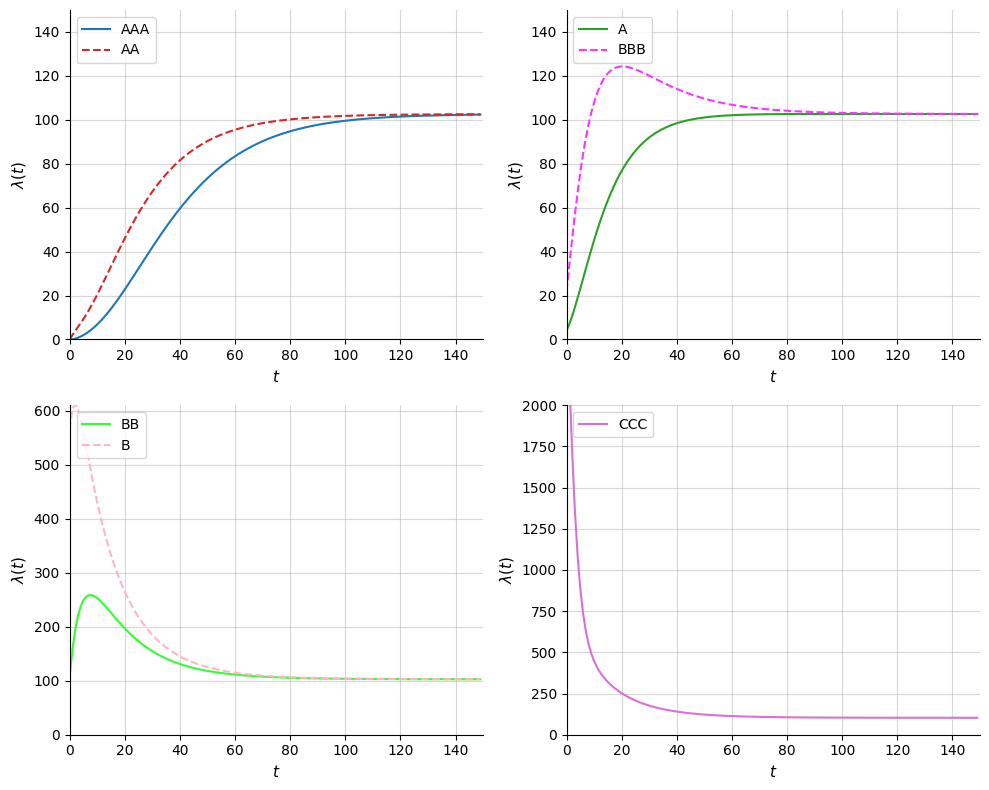

In [2]:
nMax = 150
Pn = P.copy()
t_a = np.arange(0, nMax)
PD = np.zeros((nMax, K))
for n in range(nMax):
    PD[n, :] = Pn[:, K - 1]
    Pn = Pn @ P

S = 1 - PD
S = np.vstack([np.ones((1, K)), S])  # prepend S(0) = 1
S = np.where(S == 0, np.nan, S)  # miss(S,0): guard log(0)

with np.errstate(invalid="ignore"):
    S_lead = np.vstack([S[1:], np.full((1, K), np.nan)])  # lagn(S,-1)
    lambda_a = np.log(S) - np.log(S_lead)
lambda_a = 1e4 * lambda_a[:nMax, : K - 1]

panel_plot(t_a, lambda_a, r"$\lambda(t)$", ylim_max=[150, 150, 610, 2000])


## 2. Continuous-time hazard rates via the Markov generator (`chap13_credit11b`)

`Lambda = estimate_markov_generator(logm(P))`, then
`Survival_Markov_Generator`/`Density_Markov_Generator` give `S(t)`/`f(t)`
on a fine (0.2y-step, 400y) grid; hazard `lambda(t) = f(t)/S(t)` — same
4-panel/2-rating-per-panel layout as `credit11a`, for a direct
discrete-vs-continuous-time comparison (both use the same `ylim_max`
and 150y visible x-range).

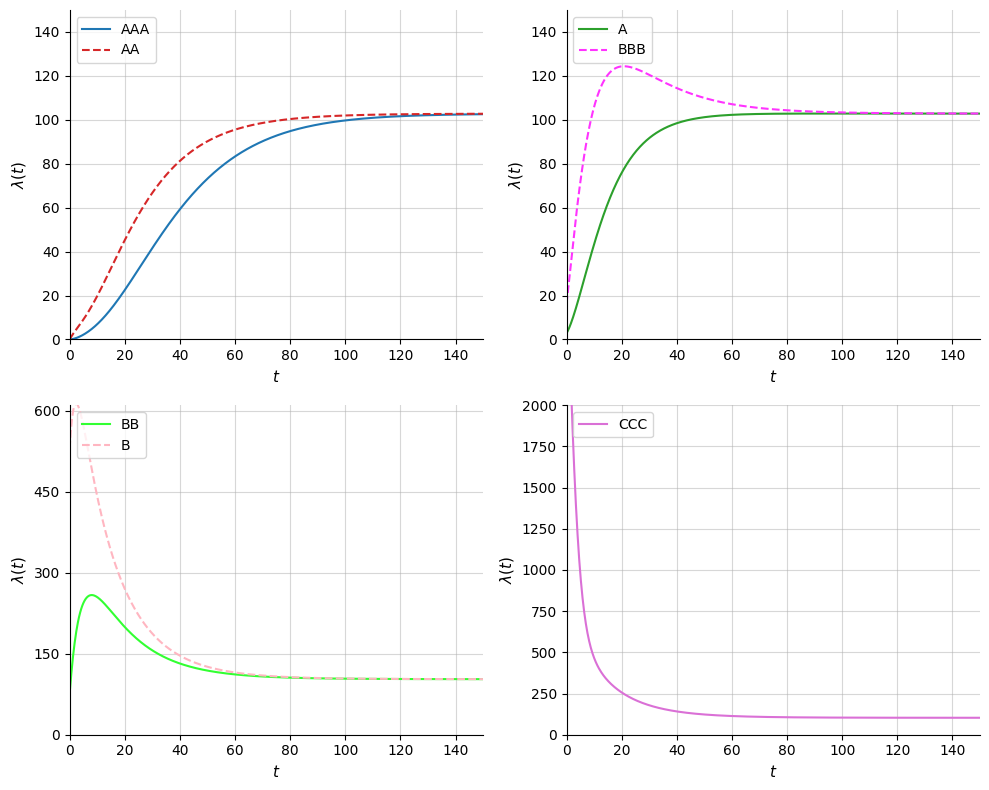

In [3]:
Lambda_raw = logm(P)
Lambda1, _ = estimate_markov_generator(Lambda_raw)

t_b = np.arange(0, 2001) * 0.2  # seqa(0, 1/5, 2001): 0..400y, 0.2y step
S_b = survival_markov_generator(t_b, Lambda1)
f_b = density_markov_generator(t_b, Lambda1)

with np.errstate(divide="ignore", invalid="ignore"):
    # column K-1 (the D rating itself) has S=0 for t>0 -> 0/0, dropped below
    lambda_b = f_b / S_b
lambda_b = 1e4 * lambda_b[:, : K - 1]

panel_plot(t_b, lambda_b, r"$\lambda(t)$", ylim_max=[150, 150, 610, 2000], ytick3=range(0, 601, 150))


## 3. Continuous-time default-time density (`chap13_credit11c`)

Same continuous-time generator setup as `credit11b`, but plots the raw
default-time density `f(t)` (`Density_Markov_Generator`'s direct
output, in units of 1e-3) instead of the hazard ratio. The source
script uses a wider x-range for the higher (AAA/AA, A/BBB) panels and a
narrower one for the lower (BB/B, CCC) panels, reflecting how much
faster the lower-rated names' default densities decay.

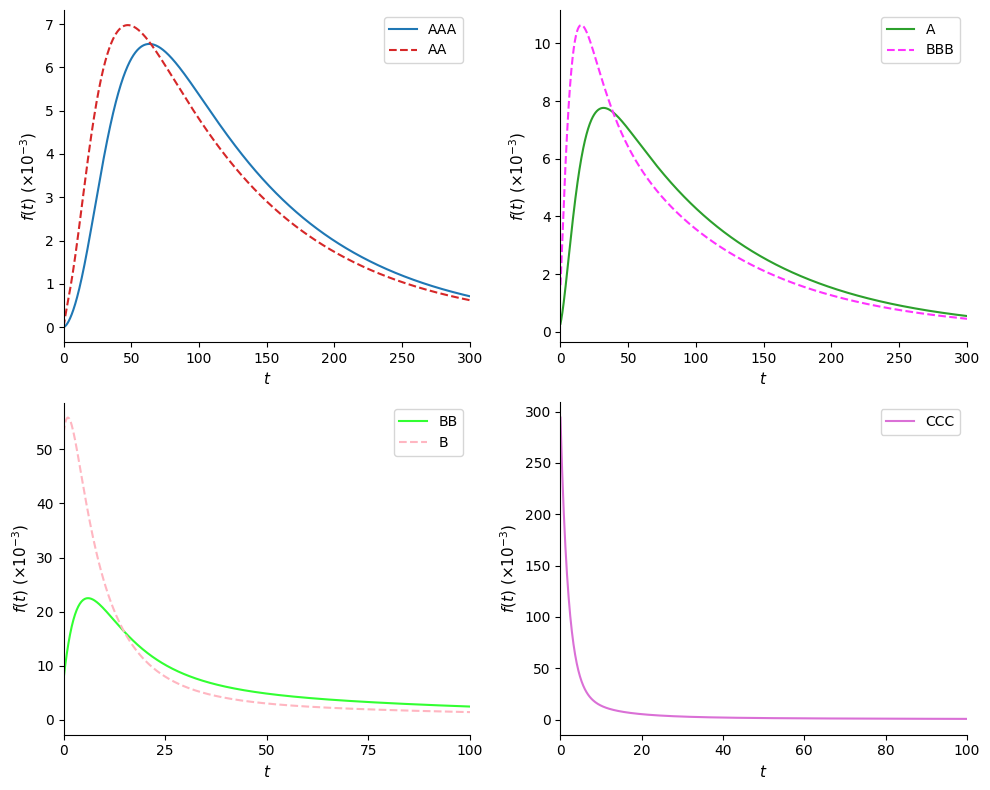

In [4]:
pdf_c = density_markov_generator(t_b, Lambda1)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
pairs = [(0, 1), (2, 3), (4, 5), (6, None)]
xlims = [300, 300, 100, 100]
for iter_i, (ax, (c1, c2)) in enumerate(zip(axes.flat, pairs)):
    ax.plot(t_b, 1e3 * pdf_c[:, c1], "-", color=colors[c1], linewidth=1.5, label=RATINGS[c1])
    if c2 is not None:
        ax.plot(t_b, 1e3 * pdf_c[:, c2], "--", color=colors[c2], linewidth=1.5, label=RATINGS[c2])
    ax.set_xlabel("$t$", fontsize=11)
    ax.set_ylabel(r"$f(t)$ ($\times 10^{-3}$)", fontsize=11)
    ax.legend(fontsize=10, loc="upper right")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlim(0, xlims[iter_i])
    if iter_i == 2:
        ax.set_xticks(range(0, 101, 25))

plt.tight_layout()
plt.show()
